# Projeto M1.2 — Pipeline 1 x Pipeline 2
UNIVALI, Processamento de Imagens, Prof. Felipe Viel.
Gustavo Corrêa de Mello, Heloisa Cavalcante Born e João Paulo Jorge Aimi.

Pipeline 1 ([notebook](config1_pipeline.ipynb)):

1. Ruído gaussiano (sigma 15)
2. Equalização de histograma
3. Filtro Gaussiano 5x5
4. High-boost (k 1,5)

Pipeline 2 ([notebook](config2_pipeline.ipynb)), a mesma sequência invertida:

1. Ruído gaussiano (sigma 15)
2. High-boost (k 1,5)
3. Filtro Gaussiano 5x5
4. Equalização de histograma

As técnicas e os parâmetros são idênticos. A única diferença é a ordem.

In [ ]:
import os
import subprocess
import sys

# Fora do repositório (Google Colab, notebook enviado sozinho) não existem as pastas
# src/ e data/: clona o repositório e entra em notebooks/ para os caminhos "../" funcionarem.
if not os.path.isdir("../src/pdi"):
    PASTA_REPO = os.path.abspath("trabalho-pdi-m1.2")
    if not os.path.isdir(PASTA_REPO):
        subprocess.run(["git", "clone", "https://github.com/mello745/trabalho-pdi-m1.2.git", PASTA_REPO], check=True)
    os.chdir(os.path.join(PASTA_REPO, "notebooks"))

sys.path.insert(0, "../src")

from pdi import pipeline
from pdi.gustavo import io_utils
from pdi.gustavo import operacoes_pontuais as op
from pdi.heloisa import ruido, suavizacao
from pdi.joao import agucamento, metricas

IMAGENS = {
    "ISIC_0014049": "../data/originais/ISIC_0014049.jpg",  # baixo contraste
    "ISIC_7236365": "../data/originais/ISIC_7236365.jpg",  # pelos densos
    "ISIC_0021531": "../data/originais/ISIC_0021531.jpg",  # bordas difusas
}

# Mesmas pipelines de config1_pipeline.ipynb e config2_pipeline.ipynb
CONFIG_1 = [
    ("degradada",  lambda im: ruido.ruido_gaussiano(im, sigma=15, semente=42)),
    ("equalizada", lambda im: op.equalizar_histograma(im)),
    ("suavizada",  lambda im: suavizacao.filtro_gaussiano(im, tamanho=5, sigma=1.0)),
    ("agucada",    lambda im: agucamento.high_boost(im, tamanho=3, sigma=1.0, k=1.5)),
]

CONFIG_2 = [
    ("degradada",  lambda im: ruido.ruido_gaussiano(im, sigma=15, semente=42)),
    ("agucada",    lambda im: agucamento.high_boost(im, tamanho=3, sigma=1.0, k=1.5)),
    ("suavizada",  lambda im: suavizacao.filtro_gaussiano(im, tamanho=5, sigma=1.0)),
    ("equalizada", lambda im: op.equalizar_histograma(im)),
]


def estagio(res, nome):
    """Imagem de um estágio da pipeline pelo nome."""
    return dict(res)[nome]


def medir(ref, img):
    return f"PSNR {metricas.psnr(ref, img):6.2f} dB  SSIM {metricas.ssim(ref, img):.3f}"

## 1. Imagens

Três melanomas do tronco posterior (ISIC), cada um com um problema diferente: contraste baixo, pelos densos e bordas difusas.

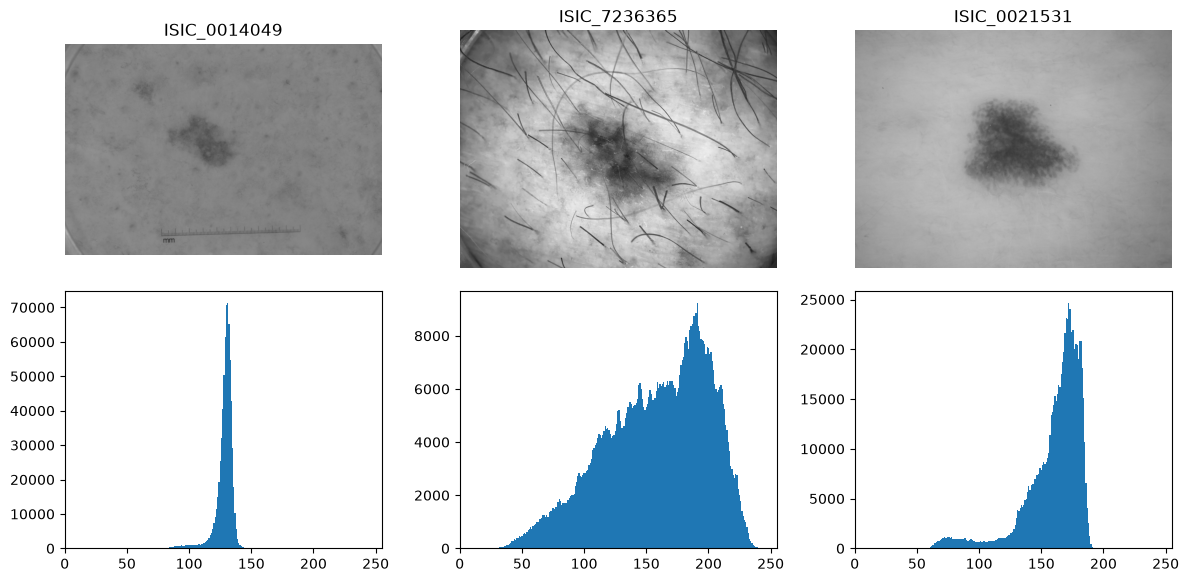

ISIC_0014049: média 128.4   contraste (desvio)   7.4
ISIC_7236365: média 158.4   contraste (desvio)  41.6
ISIC_0021531: média 160.2   contraste (desvio)  23.5


In [2]:
originais = {n: io_utils.carregar_cinza(c, largura_max=1024) for n, c in IMAGENS.items()}
io_utils.mostrar(list(originais.values()), list(originais.keys()))

for n, img in originais.items():
    print(f"{n}: média {img.mean():5.1f}   contraste (desvio) {img.std():5.1f}")

## 2. Executando as duas pipelines

As duas usam a mesma semente de ruído, então partem da mesma imagem degradada.

In [3]:
r1 = {n: pipeline.executar(img, CONFIG_1) for n, img in originais.items()}
r2 = {n: pipeline.executar(img, CONFIG_2) for n, img in originais.items()}

## 3. Operação pontual: equalização nas três imagens

Aplicada na original para isolar o efeito.

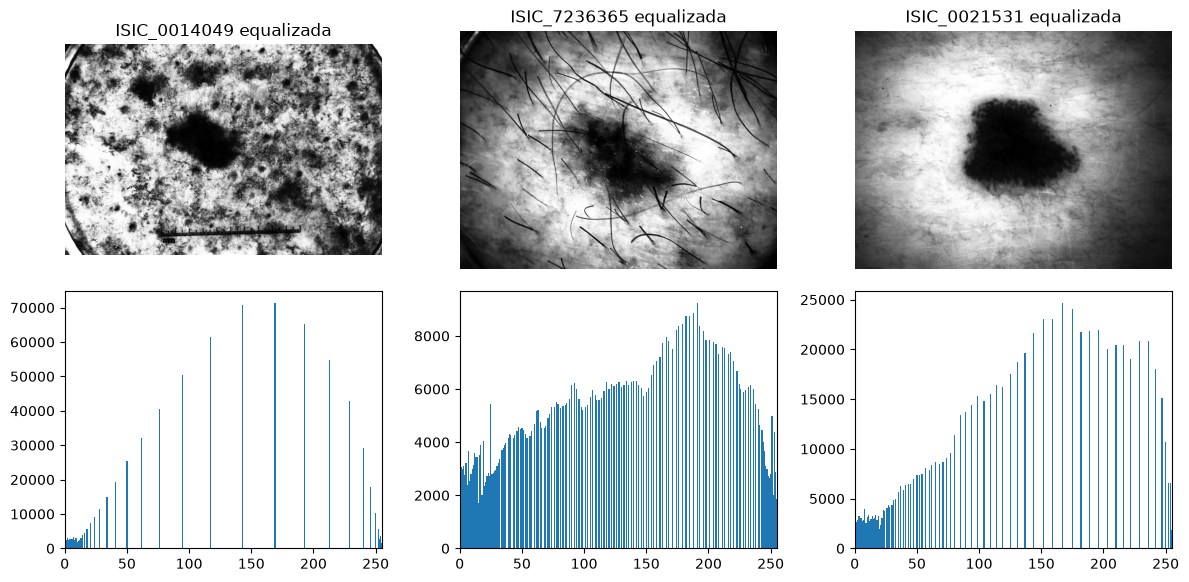

ISIC_0014049: contraste   7.4 ->  75.0
ISIC_7236365: contraste  41.6 ->  73.8
ISIC_0021531: contraste  23.5 ->  74.4


In [4]:
eq = {n: op.equalizar_histograma(img) for n, img in originais.items()}
io_utils.mostrar(list(eq.values()), [f"{n} equalizada" for n in eq])

for n, img in originais.items():
    print(f"{n}: contraste {img.std():5.1f} -> {eq[n].std():5.1f}")

A equalização espalha os tons por toda a faixa de 0 a 255 e multiplica o contraste, mas o histograma fica "em pente": ela não cria tons novos, só redistribui os existentes.

## 4. Estágio por estágio

A mesma imagem (ISIC_0021531) nas duas pipelines.

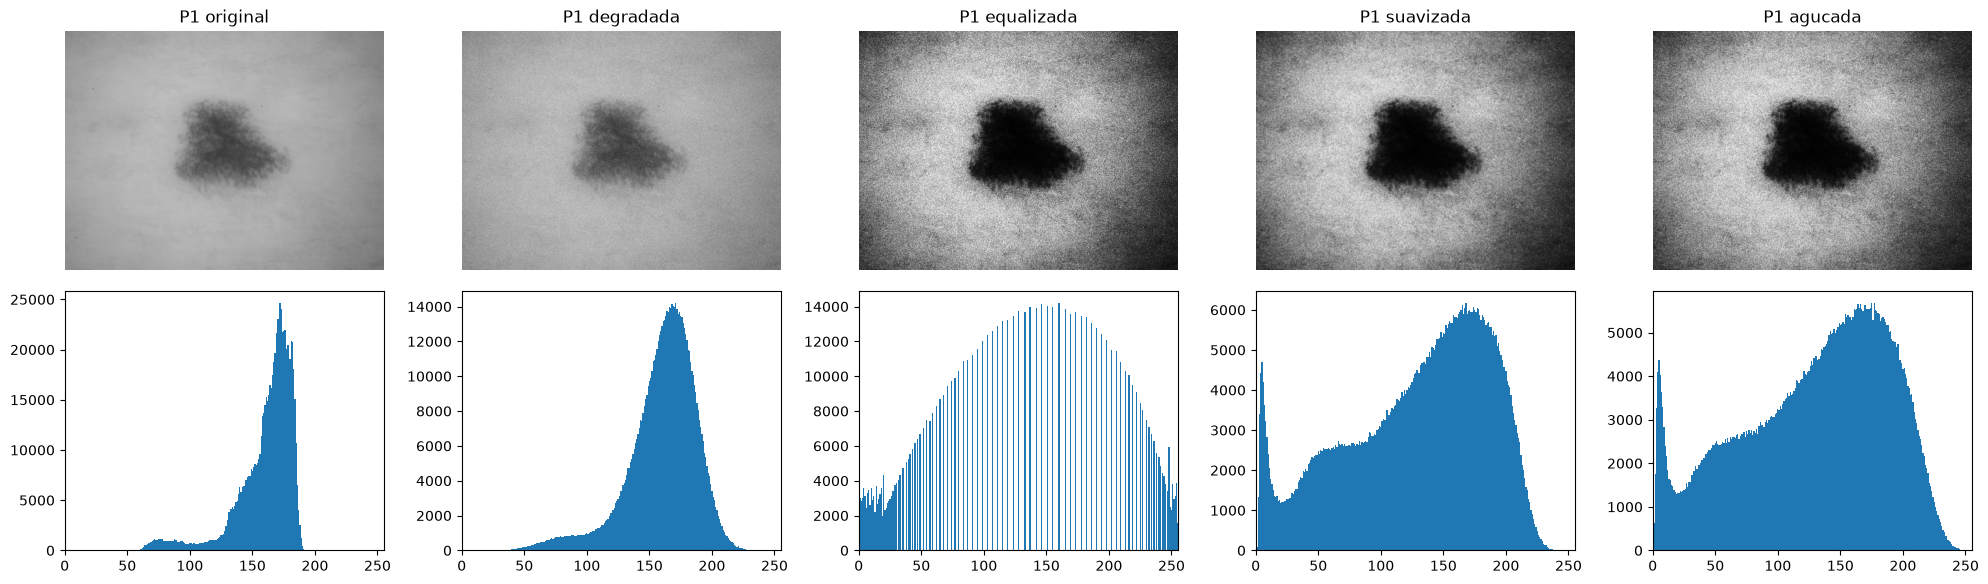

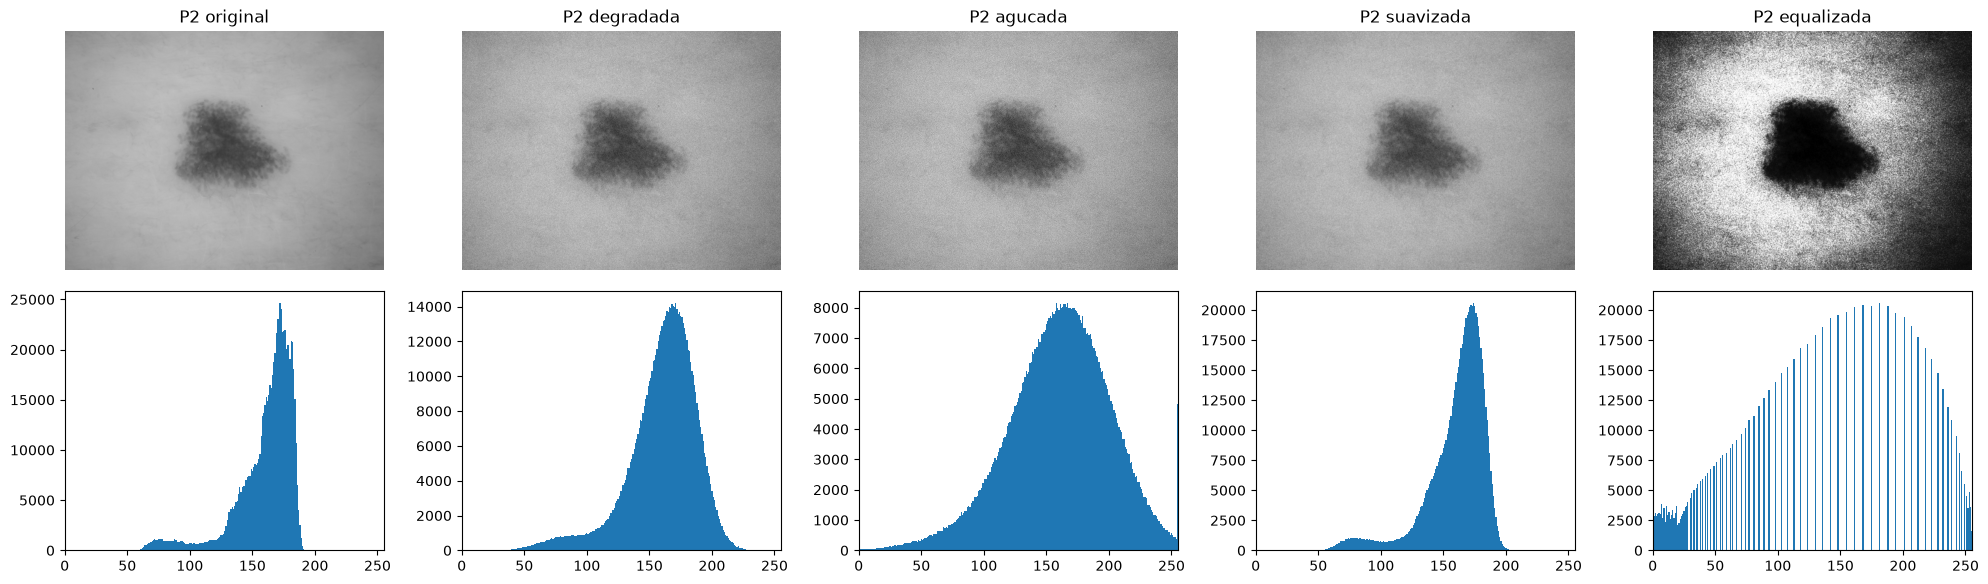

ISIC_0014049


  P1: degradada SSIM 0.240   equalizada SSIM 0.022   suavizada SSIM 0.205   agucada SSIM 0.119


  P2: degradada SSIM 0.240   agucada SSIM 0.063   suavizada SSIM 0.679   equalizada SSIM 0.038
ISIC_7236365


  P1: degradada SSIM 0.401   equalizada SSIM 0.227   suavizada SSIM 0.617   agucada SSIM 0.513


  P2: degradada SSIM 0.401   agucada SSIM 0.177   suavizada SSIM 0.767   equalizada SSIM 0.473
ISIC_0021531


  P1: degradada SSIM 0.232   equalizada SSIM 0.035   suavizada SSIM 0.276   agucada SSIM 0.168


  P2: degradada SSIM 0.232   agucada SSIM 0.059   suavizada SSIM 0.677   equalizada SSIM 0.113


In [5]:
n = "ISIC_0021531"
io_utils.mostrar(pipeline.imagens(r1[n]), [f"P1 {e}" for e in pipeline.nomes(r1[n])])
io_utils.mostrar(pipeline.imagens(r2[n]), [f"P2 {e}" for e in pipeline.nomes(r2[n])])

for n, img in originais.items():
    print(n)
    for rotulo, res in [("P1", r1[n]), ("P2", r2[n])]:
        print("  " + rotulo + ": " + "   ".join(f"{e} SSIM {metricas.ssim(img, x):.3f}" for e, x in res[1:]))

1. Na pipeline 1 a equalização vem logo após o ruído e derruba o SSIM (0,022 a 0,227); o Gaussiano e o high-boost seguintes recuperam parte da estrutura.
2. Na pipeline 2 o high-boost aguça o ruído (SSIM 0,059 a 0,177), e o Gaussiano logo em seguida quase desfaz o aguçamento. Esse estágio intermediário é o melhor do trabalho (SSIM 0,677 a 0,767; PSNR 31,25 a 32,64 dB no [notebook da pipeline 2](config2_pipeline.ipynb)).
3. A equalização no fim da pipeline 2 estica o ruído que sobrou, sem nenhuma etapa depois para corrigir.

## 5. Aguçamento: por que high-boost e não só bordas

O Sobel mostra apenas as bordas já o high-boost soma esse detalhe à imagem inteira.

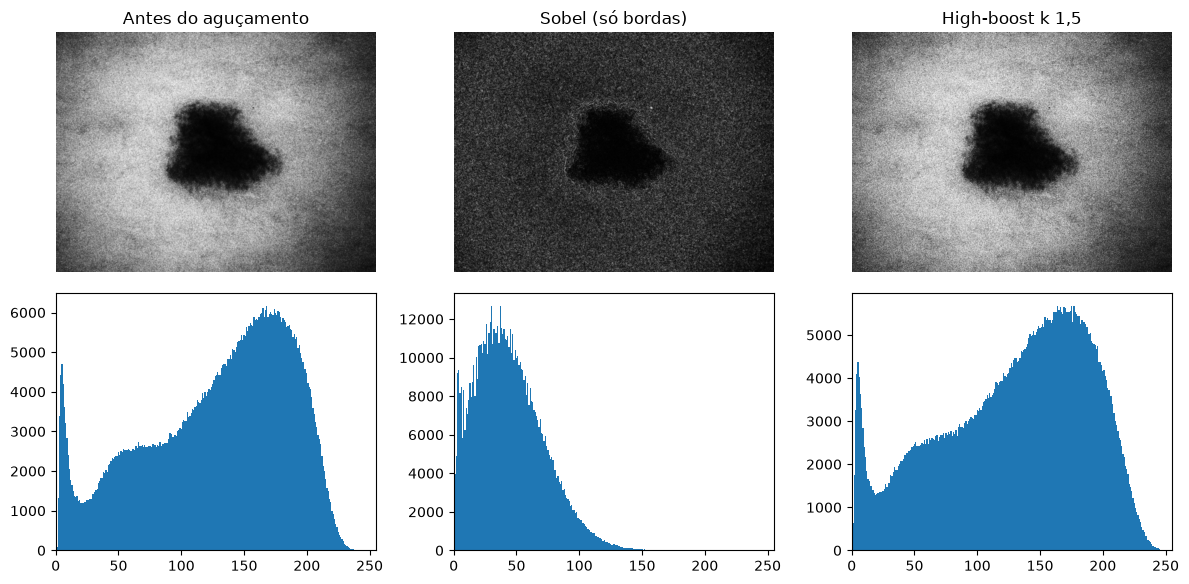

In [6]:
n = "ISIC_0021531"
base = estagio(r1[n], "suavizada")
io_utils.mostrar([base, agucamento.sobel_edges(base), estagio(r1[n], "agucada")],
                 ["Antes do aguçamento", "Sobel (só bordas)", "High-boost k 1,5"])

## 6. Resultado final lado a lado

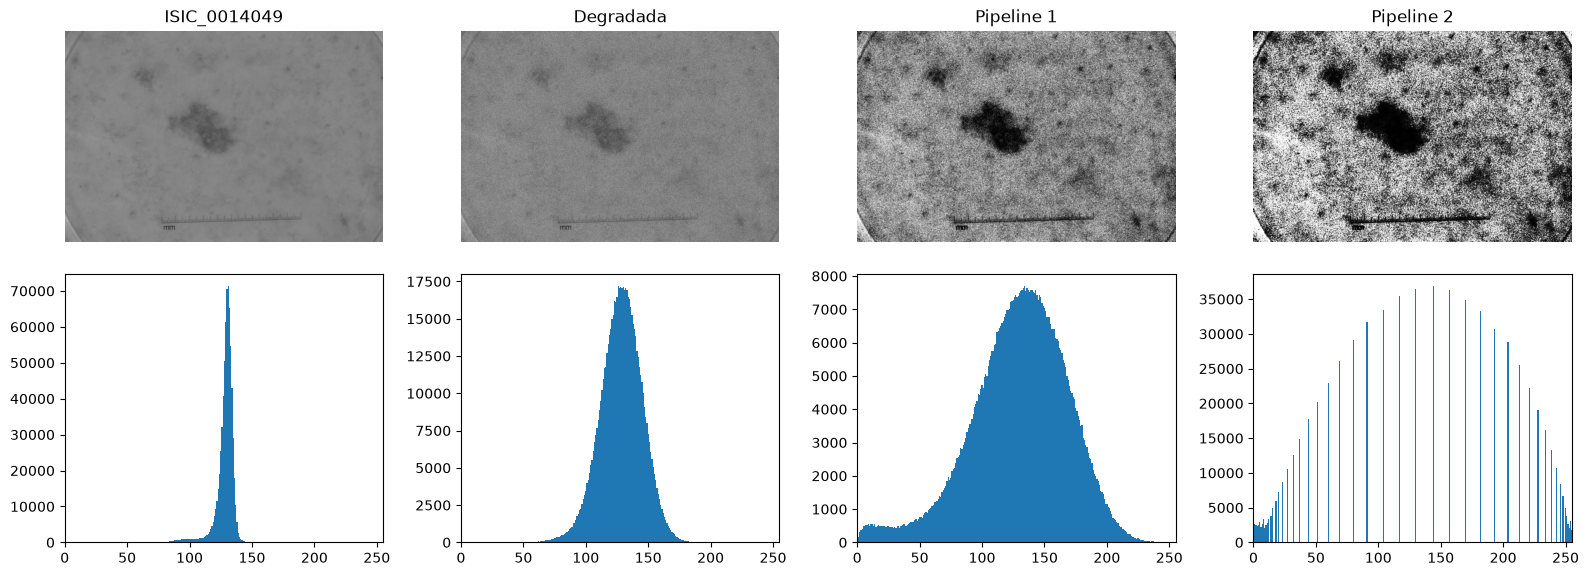

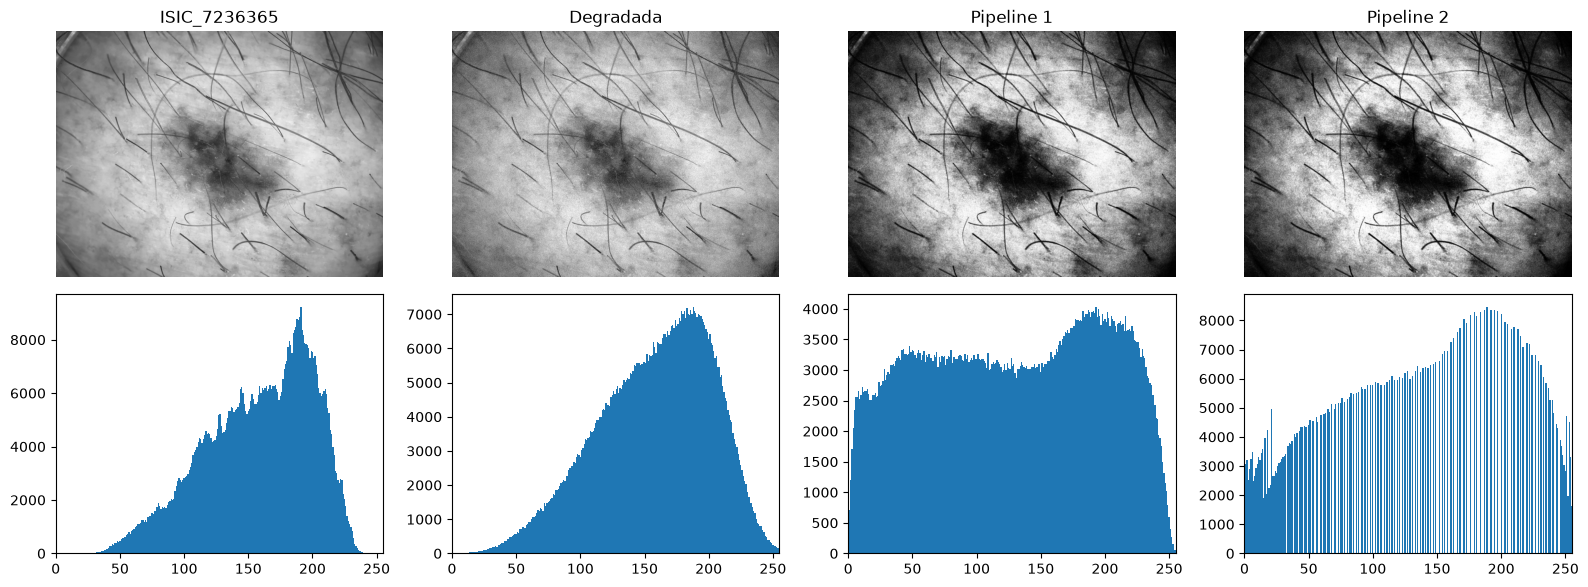

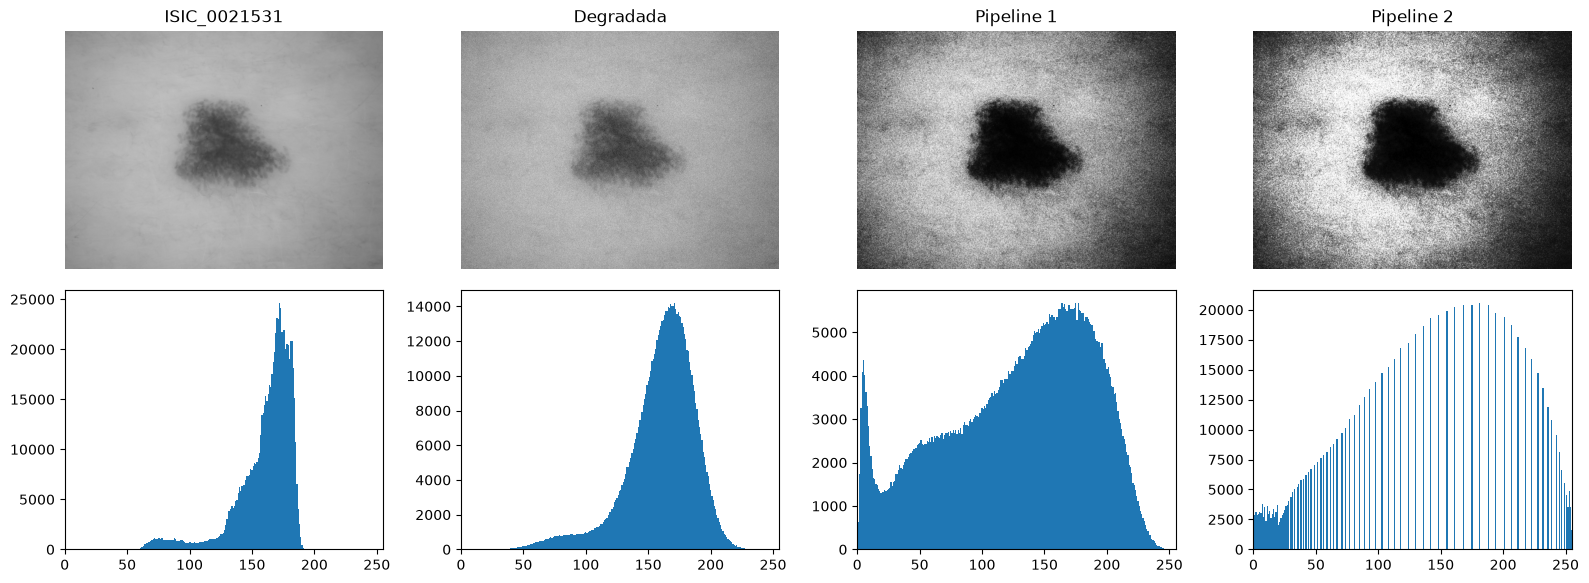

In [7]:
for n, img in originais.items():
    f1, f2 = pipeline.final(r1[n]), pipeline.final(r2[n])
    io_utils.mostrar([img, estagio(r1[n], "degradada"), f1, f2], [n, "Degradada", "Pipeline 1", "Pipeline 2"])

    io_utils.salvar(estagio(r1[n], "degradada"), f"../resultados/{n}_degradada.png")
    io_utils.salvar(f1, f"../resultados/{n}_config1.png")
    io_utils.salvar(f2, f"../resultados/{n}_config2.png")

## 7. Métricas finais

PSNR mede o erro de intensidade (remoção de ruído) e SSIM mede a preservação da estrutura. A referência é a original sem ruído.

In [8]:
for n, img in originais.items():
    deg, f1, f2 = estagio(r1[n], "degradada"), pipeline.final(r1[n]), pipeline.final(r2[n])
    print(n)
    print(f"  degradada   {medir(img, deg)}")
    print(f"  pipeline 1  {medir(img, f1)}")
    print(f"  pipeline 2  {medir(img, f2)}")

ISIC_0014049


  degradada   PSNR  24.60 dB  SSIM 0.240


  pipeline 1  PSNR  17.51 dB  SSIM 0.119


  pipeline 2  PSNR  11.22 dB  SSIM 0.038
ISIC_7236365


  degradada   PSNR  24.61 dB  SSIM 0.401


  pipeline 1  PSNR  15.52 dB  SSIM 0.513


  pipeline 2  PSNR  14.85 dB  SSIM 0.473
ISIC_0021531


  degradada   PSNR  24.60 dB  SSIM 0.232


  pipeline 1  PSNR  14.10 dB  SSIM 0.168


  pipeline 2  PSNR  11.98 dB  SSIM 0.113


## 8. Conclusão

1. A pipeline 1 se sai melhor nas três imagens e nas duas métricas.
2. Com as mesmas técnicas, só a ordem mudou o resultado: a ordem das etapas é uma decisão tão importante quanto a escolha das técnicas.
3. A equalização estica qualquer ruído presente. Ela precisa de uma suavização depois dela, e é melhor que não seja a última etapa.
4. Aguçamento antes da suavização é perdida: o Gaussiano desfaz o que o high-boost acabou de realçar.
5. Mesmo a pipeline 1 tem pontos fracos: o fundo continua granulado e os cantos escurecem na ISIC_0021531.
6. Limitação: PSNR e SSIM medem fidelidade à original, e a equalização muda as intensidades de propósito, por isso as métricas precisam ser lidas junto com as imagens.

## 9. Teste com uma imagem diferente

Teste realizado nas duas pipelines.

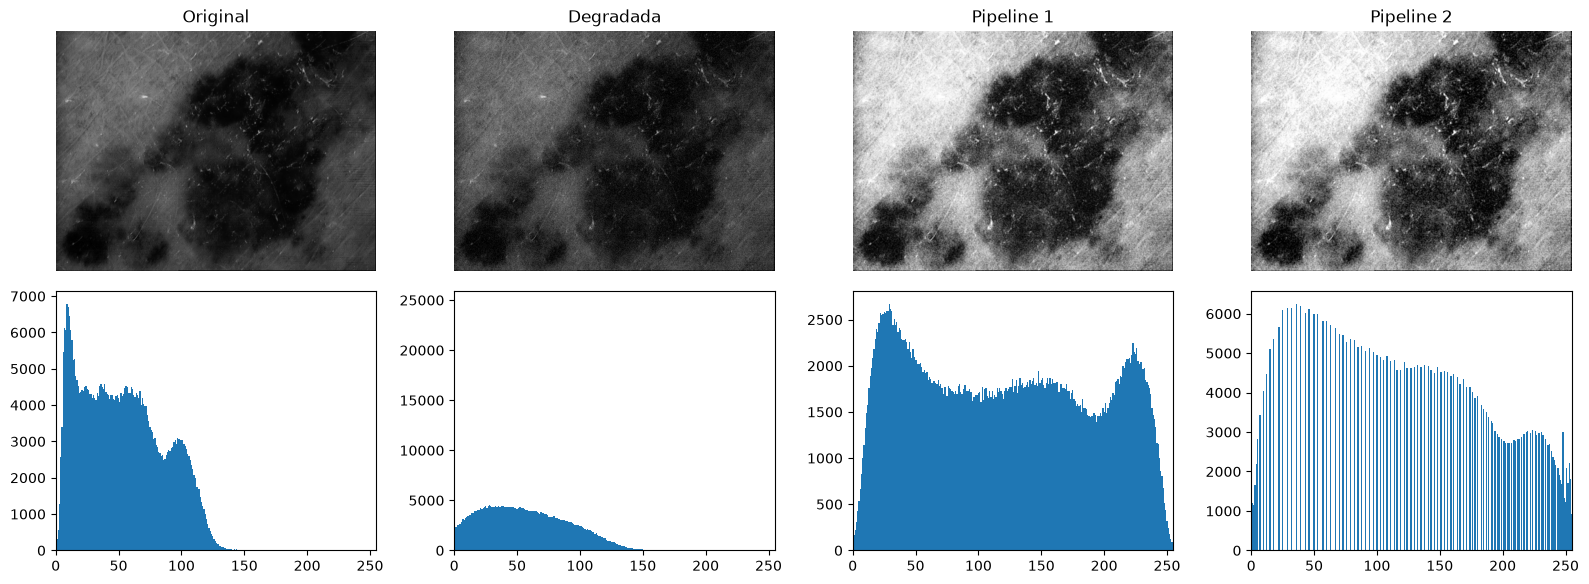

Pipeline 1: PSNR  10.18 dB  SSIM 0.375
Pipeline 2: PSNR   9.37 dB  SSIM 0.339


In [9]:
IMAGEM_TESTE = "../data/originais/ISIC_0112420.jpg"

img = io_utils.carregar_cinza(IMAGEM_TESTE, largura_max=1024)
t1, t2 = pipeline.executar(img, CONFIG_1), pipeline.executar(img, CONFIG_2)
io_utils.mostrar([img, estagio(t1, "degradada"), pipeline.final(t1), pipeline.final(t2)],
                 ["Original", "Degradada", "Pipeline 1", "Pipeline 2"])
print(f"Pipeline 1: {medir(img, pipeline.final(t1))}")
print(f"Pipeline 2: {medir(img, pipeline.final(t2))}")